In [1]:
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt
import joblib

In [2]:
X = pd.read_csv("data/pca_8_components.csv")
y = pd.read_csv("data/labels.csv").squeeze()

In [18]:
print(X.shape, y.shape)

(639846, 8) (639846,)


In [4]:
X_sample = X.sample(n=100000, random_state=42)

GMM Hyperparameter Tuning

In [7]:
results = []

for k in range(2, 11):  # same reduced range
    for cov in ['full', 'tied', 'diag', 'spherical']:
        
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov,
            random_state=42
        )
        
        gmm.fit(X_sample)
        
        bic = gmm.bic(X_sample)
        aic = gmm.aic(X_sample)
        
        results.append((k, cov, bic, aic))
        print(f"K={k}, cov={cov}, BIC={bic:.2f}, AIC={aic:.2f}")

K=2, cov=full, BIC=1504770.45, AIC=1503923.80
K=2, cov=tied, BIC=2753620.42, AIC=2753116.24
K=2, cov=diag, BIC=2008053.26, AIC=2007739.33
K=2, cov=spherical, BIC=2396044.30, AIC=2395863.56
K=3, cov=full, BIC=1079162.41, AIC=1077887.68
K=3, cov=tied, BIC=2657559.13, AIC=2656969.33
K=3, cov=diag, BIC=1786405.64, AIC=1785930.00
K=3, cov=spherical, BIC=2163624.08, AIC=2163348.21
K=4, cov=full, BIC=359001.99, AIC=357299.17
K=4, cov=tied, BIC=2396081.18, AIC=2395405.76
K=4, cov=diag, BIC=1731008.58, AIC=1730371.21
K=4, cov=spherical, BIC=2130129.69, AIC=2129758.68
K=5, cov=full, BIC=55444.09, AIC=53313.20
K=5, cov=tied, BIC=2234870.27, AIC=2234109.24
K=5, cov=diag, BIC=1487133.15, AIC=1486334.07
K=5, cov=spherical, BIC=1819706.78, AIC=1819240.65
K=6, cov=full, BIC=-34315.38, AIC=-36874.36
K=6, cov=tied, BIC=2137377.63, AIC=2136530.98
K=6, cov=diag, BIC=1461964.39, AIC=1461003.58
K=6, cov=spherical, BIC=1772059.99, AIC=1771498.73
K=7, cov=full, BIC=-197634.50, AIC=-200621.56
K=7, cov=tied, BI

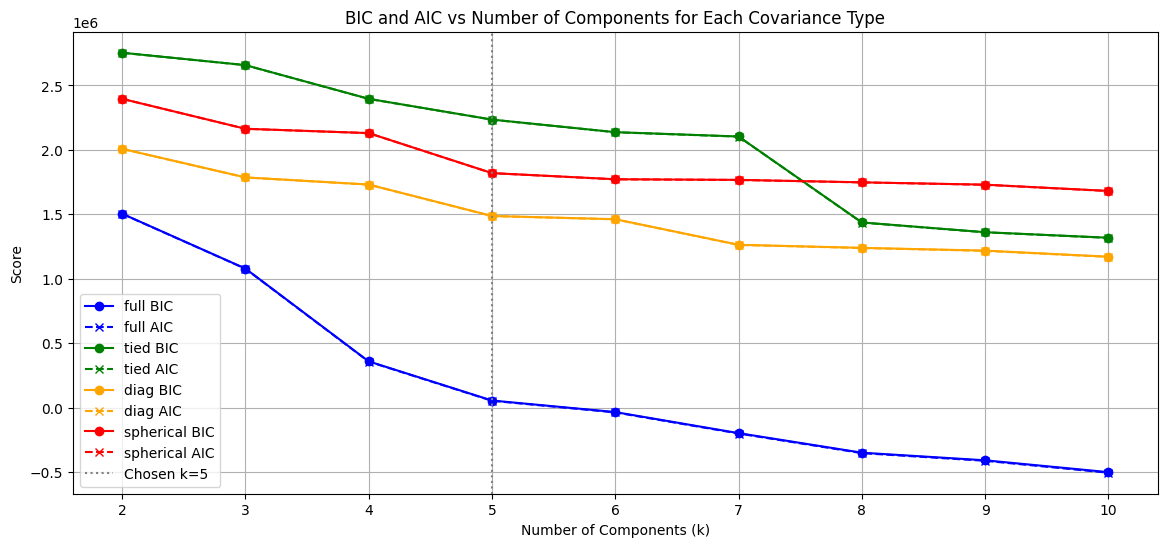

In [11]:
# Convert results to a DataFrame
df = pd.DataFrame(results, columns=['k', 'covariance_type', 'BIC', 'AIC'])

cov_types = df['covariance_type'].unique()
colors = {'full':'blue', 'tied':'green', 'diag':'orange', 'spherical':'red'}

plt.figure(figsize=(14, 6))

for cov in cov_types:
    subset = df[df['covariance_type'] == cov]
    plt.plot(subset['k'], subset['BIC'], marker='o', color=colors[cov], linestyle='-', label=f'{cov} BIC')
    plt.plot(subset['k'], subset['AIC'], marker='x', color=colors[cov], linestyle='--', label=f'{cov} AIC')

# Mark k=5 as chosen elbow
plt.axvline(x=5, color='gray', linestyle=':', label='Chosen k=5')

plt.xlabel('Number of Components (k)')
plt.ylabel('Score')
plt.title('BIC and AIC vs Number of Components for Each Covariance Type')
plt.xticks(range(2, 11))
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# Initialize and fit the GMM
gmm = GaussianMixture(
    n_components=5,
    covariance_type='full',
    random_state=42
)
gmm.fit(X)

# Predict cluster labels
gmm_labels = gmm.predict(X)

# Optional: cluster probabilities for each point
gmm_probs = gmm.predict_proba(X)

In [4]:
joblib.dump(gmm, "models/gmm_model.pkl")

['models/gmm_model.pkl']

Evaluation

In [13]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# --- Internal Validation ---
silhouette_gmm = silhouette_score(X, gmm_labels)
dbi_gmm = davies_bouldin_score(X, gmm_labels)

# --- External Validation ---
ari_gmm = adjusted_rand_score(y, gmm_labels)

# --- Print Results ---
print("GMM Evaluation Metrics")
print(f"Silhouette Score: {silhouette_gmm:.4f}")
print(f"Davies-Bouldin Index: {dbi_gmm:.4f}")
print(f"Adjusted Rand Index: {ari_gmm:.4f}")

GMM Evaluation Metrics
Silhouette Score: 0.3560
Davies-Bouldin Index: 1.3053
Adjusted Rand Index: 0.2478


Visualization of Mapping

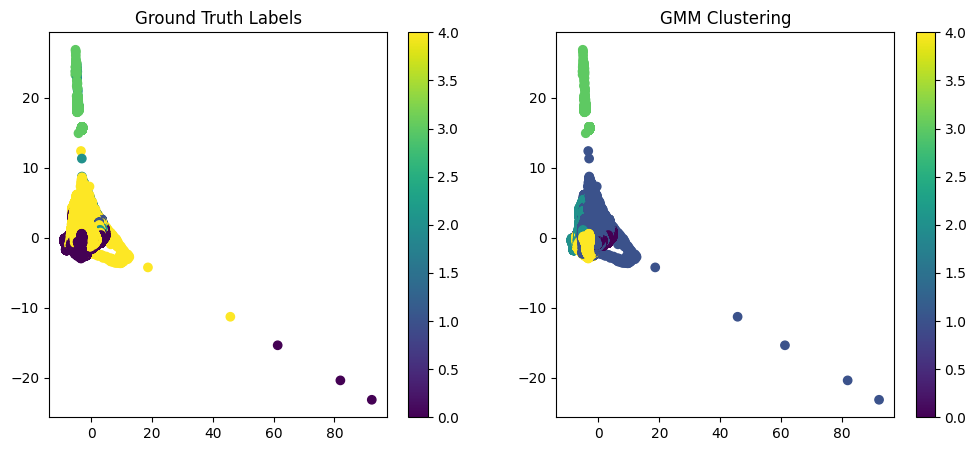

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Ground Truth ---
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis')
axes[0].set_title("Ground Truth Labels")
plt.colorbar(scatter1, ax=axes[0])

# --- Clustering Result ---
scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=gmm_labels, cmap='viridis')
axes[1].set_title("GMM Clustering")
plt.colorbar(scatter2, ax=axes[1])

plt.show()

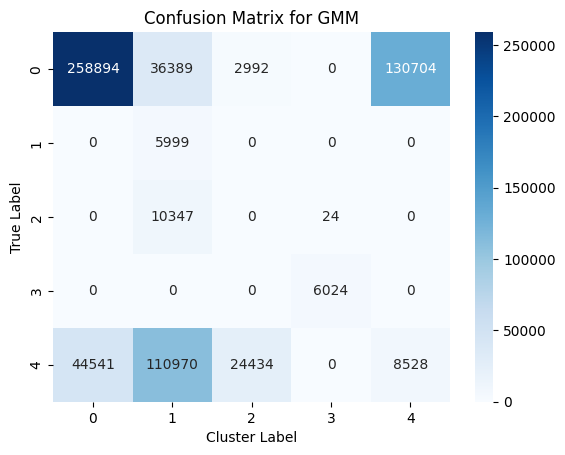

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y, gmm_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Cluster Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for GMM")
plt.show()